# Session 3: Baby MMM from Scratch -- OLS Foundation

**Marketing Science Bootcamp -- Week 2, Live Session**

---

In this session we build a full Marketing Mix Model using **Ordinary Least Squares (OLS)**. We will:

1. Apply adstock + saturation transformations via grid search.
2. Select the best transformation per channel (highest correlation with KPI).
3. Fit an OLS model and inspect diagnostics.
4. Decompose sales into channel contributions.
5. Iterate on model specs and compare results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import sys

# Add project root for utils
sys.path.insert(0, "../..")

from utils.mmm_utils import (
    adstock_geometric,
    saturation_hill,
    geometric_hill_transform,
    best_transformation,
    build_ols_model,
    model_diagnostics,
    compute_contributions,
    create_contribution_plot,
    compute_decomp_rssd,
    PARAM_RANGES,
)
from utils.eda_utils import load_workshop_data, load_config

# Plotting defaults
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

print("Setup complete.")

Setup complete.


In [2]:
# Load data and configuration
data = load_workshop_data("../../data/MMM_Workshop_Data.xlsx")
config = load_config("../../data/config_file.csv")

# Extract key variable lists
dv = config["dependent_var"]
time_col = config["time_column"]
paid_media = config["paid_media_spends"]
competition = config["competition_spend_vars"]
untransformed = config["untransformed_vars"]
tv_vars = config["tv_vars"]
traditional_vars = config["traditional_vars"]
atl_vars = config["atl_vars"]
digital_vars = config["digital_vars"]

y = data[dv].values

print(f"Dependent variable: {dv}")
print(f"Time column: {time_col}")
print(f"Paid media variables ({len(paid_media)}): {paid_media}")
print(f"TV vars: {tv_vars}")
print(f"Traditional vars: {traditional_vars}")
print(f"ATL (competition) vars: {atl_vars}")
print(f"Digital vars: {digital_vars}")
print(f"Untransformed vars: {untransformed}")
print(f"\nData shape: {data.shape}")

Dependent variable: Sales_Volume_Total
Time column: Month
Paid media variables (27): ['TV_GRP', 'TV_Spends', 'Radio_Spends', 'Outdoor_Spends', 'Paid_Search_Spends', 'Programmatic_Display_Spends', 'Google_Display_Spend', 'Direct_Display_Spend', 'Meta1_Spends', 'Programmatic_Video_Spends', 'Youtube_Spends', 'Meta_Spends_Agg', 'Paid_Search_Impressions', 'Direct_Display_Impressions', 'Programmatic_Display_Impressions', 'Google_Display_Impressions', 'Online_Video_Impressions', 'Meta_Agg_Impressions', 'YouTube_Views', 'Paid_Search_Clicks', 'META_Clicks', 'Online_Video_Views', 'Influencer_Marketing_Spends', 'Meta2_Spends', 'Brand_B_ATL_Spends', 'Brand_PH_ATL_Spends', 'Brand_P_ATL_Spends']
TV vars: ['TV_GRP', 'TV_Spends']
Traditional vars: ['Radio_Spends', 'Outdoor_Spends']
ATL (competition) vars: ['Brand_B_ATL_Spends', 'Brand_PH_ATL_Spends', 'Brand_P_ATL_Spends']
Digital vars: ['Paid_Search_Spends', 'Programmatic_Display_Spends', 'Google_Display_Spend', 'Direct_Display_Spend', 'Meta1_Spends',

---

## Step 1: Apply Transformations via Grid Search

Instead of hand-picking parameters (like we did in Notebook 2), we now **search** over a grid of `(theta, alpha, gamma)` values for each channel. For every combination, we:

1. Apply geometric adstock with that theta.
2. Apply Hill saturation with that alpha and gamma.
3. Store the resulting transformed series.

Later we will pick the combination that yields the highest correlation with the dependent variable.

In [3]:
# Review the default parameter ranges
for channel_type, ranges in PARAM_RANGES.items():
    n_combos = len(ranges["theta"]) * len(ranges["alpha"]) * len(ranges["gamma"])
    print(f"{channel_type:>12}: theta {ranges['theta'][[0,-1]]}, "
          f"alpha {ranges['alpha'][[0,-1]]}, "
          f"gamma {ranges['gamma'][[0,-1]]} "
          f"-> {n_combos} combinations")

          tv: theta [0.3 0.8], alpha [0.5 3. ], gamma [0.3 1. ] -> 1248 combinations
     digital: theta [0.  0.3], alpha [0.5 3. ], gamma [0.3 1. ] -> 832 combinations
 traditional: theta [0.1 0.4], alpha [0.5 3. ], gamma [0.3 1. ] -> 832 combinations
     organic: theta [0.1 0.4], alpha [0.5 3. ], gamma [0.3 1. ] -> 832 combinations
         atl: theta [0.1 0.8], alpha [0.5 3. ], gamma [0.3 1. ] -> 1664 combinations


In [4]:
# Apply grid search transformations for each variable category

# TV variables
transformed_tv = {}
for var in tv_vars:
    transformed_tv[var] = geometric_hill_transform(
        data[var], var,
        theta_range=PARAM_RANGES["tv"]["theta"],
        alpha_range=PARAM_RANGES["tv"]["alpha"],
        gamma_range=PARAM_RANGES["tv"]["gamma"],
    )
    print(f"{var}: {transformed_tv[var].shape[1] - 1} transformed columns")

# Digital variables
transformed_digital = {}
for var in digital_vars:
    transformed_digital[var] = geometric_hill_transform(
        data[var], var,
        theta_range=PARAM_RANGES["digital"]["theta"],
        alpha_range=PARAM_RANGES["digital"]["alpha"],
        gamma_range=PARAM_RANGES["digital"]["gamma"],
    )
    print(f"{var}: {transformed_digital[var].shape[1] - 1} transformed columns")

# Traditional variables
transformed_traditional = {}
for var in traditional_vars:
    transformed_traditional[var] = geometric_hill_transform(
        data[var], var,
        theta_range=PARAM_RANGES["traditional"]["theta"],
        alpha_range=PARAM_RANGES["traditional"]["alpha"],
        gamma_range=PARAM_RANGES["traditional"]["gamma"],
    )
    print(f"{var}: {transformed_traditional[var].shape[1] - 1} transformed columns")

# ATL (competition) variables
transformed_atl = {}
for var in atl_vars:
    transformed_atl[var] = geometric_hill_transform(
        data[var], var,
        theta_range=PARAM_RANGES["atl"]["theta"],
        alpha_range=PARAM_RANGES["atl"]["alpha"],
        gamma_range=PARAM_RANGES["atl"]["gamma"],
    )
    print(f"{var}: {transformed_atl[var].shape[1] - 1} transformed columns")

print("\nGrid search transformations complete.")

TV_GRP: 1248 transformed columns


/Users/guilhermediaz-berrio/1-Projects/MavenCourse/cohort-Mar26/week-2/session-3/../../utils/mmm_utils.py:217: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  transformed[col] = saturation_hill(adstocked, alpha, gamma)


TV_Spends: 1248 transformed columns
Paid_Search_Spends: 832 transformed columns
Programmatic_Display_Spends: 832 transformed columns
Google_Display_Spend: 832 transformed columns
Direct_Display_Spend: 832 transformed columns
Meta1_Spends: 832 transformed columns
Programmatic_Video_Spends: 832 transformed columns
Youtube_Spends: 832 transformed columns
Meta_Spends_Agg: 832 transformed columns
Paid_Search_Impressions: 832 transformed columns
Direct_Display_Impressions: 832 transformed columns
Programmatic_Display_Impressions: 832 transformed columns
Google_Display_Impressions: 832 transformed columns
Online_Video_Impressions: 832 transformed columns
Meta_Agg_Impressions: 832 transformed columns
YouTube_Views: 832 transformed columns
Paid_Search_Clicks: 832 transformed columns
META_Clicks: 832 transformed columns
Online_Video_Views: 832 transformed columns
Influencer_Marketing_Spends: 832 transformed columns
Meta2_Spends: 832 transformed columns
Radio_Spends: 832 transformed columns
Outdo

---

## Step 2: Select Best Transformation per Variable

For each variable, we pick the `(theta, alpha, gamma)` combination that produces the **highest Pearson correlation** with the dependent variable (`Sales_Volume_Total`).

For competition variables, we use `ascending=True` to select the most **negative** correlation (competitor spend should hurt our sales).

In [5]:
# Combine all transformed DataFrames
all_transformed = {}
all_transformed.update(transformed_tv)
all_transformed.update(transformed_digital)
all_transformed.update(transformed_traditional)
all_transformed.update(transformed_atl)

# Find best transformation for each variable
best_results = []

for var, tf_df in all_transformed.items():
    # Competition vars: look for negative correlation
    is_competition = var in competition
    best_col, corr, pval, cor_df = best_transformation(
        tf_df, y, var, ascending=is_competition
    )
    best_results.append({
        "Variable": var,
        "Best_Column": best_col,
        "Correlation": corr,
        "P_Value": pval,
        "Is_Competition": is_competition,
    })

best_df = pd.DataFrame(best_results)
best_df = best_df.sort_values("Correlation", key=abs, ascending=False)
print("Best transformation per variable:")
best_df

Best transformation per variable:


,Variable,Best_Column,Correlation,P_Value,Is_Competition
16,YouTube_Views,YouTube_Views_0.3_0.5_0.3,0.814779,1.468208e-09,False
8,Youtube_Spends,Youtube_Spends_0.3_0.5_0.3,0.803835,3.559340e-09,False
18,META_Clicks,META_Clicks_0.3_0.5_0.3,0.786003,1.346865e-08,False
15,Meta_Agg_Impressions,Meta_Agg_Impressions_0.3_0.5_0.3,0.768737,4.358204e-08,False
9,Meta_Spends_Agg,Meta_Spends_Agg_0.3_0.5_0.3,0.752305,1.218236e-07,False
19,Online_Video_Views,Online_Video_Views_0.3_0.5_0.3,0.696138,2.424460e-06,False
13,Google_Display_Impressions,Google_Display_Impressions_0.3_0.5_0.3,0.685376,3.987060e-06,False
6,Meta1_Spends,Meta1_Spends_0.3_0.5_0.3,0.666143,9.226506e-06,False
5,Direct_Display_Spend,Direct_Display_Spend_0.3_0.5_0.3,0.661313,1.128383e-05,False
4,Google_Display_Spend,Google_Display_Spend_0.3_0.5_0.3,0.647550,1.964424e-05,False


---

## Step 3: Build OLS Model (Model 1)

We select a subset of variables for our first model specification. A good starting point:

- **Media channels:** TV_Spends, TV_GRP, a few digital channels
- **Controls:** Inflation_Rate, Average_Price_Total
- **Competition:** Brand_B_ATL_Spends

In [6]:
# Model 1 specification: select variables to include
model1_vars = [
    "TV_Spends",
    "TV_GRP",
    "Paid_Search_Spends",
    "Programmatic_Display_Spends",
    "Meta_Spends_Agg",
    "Radio_Spends",
    "Brand_B_ATL_Spends",
]

# Build X matrix using best transformations
X_model1 = pd.DataFrame()

for var in model1_vars:
    best_row = best_df[best_df["Variable"] == var]
    if best_row.empty:
        print(f"WARNING: {var} not found in best_df, using raw values")
        X_model1[var] = data[var].values
    else:
        best_col = best_row["Best_Column"].values[0]
        X_model1[best_col] = all_transformed[var][best_col].values
        print(f"{var} -> {best_col} (r = {best_row['Correlation'].values[0]:.4f})")

# Add untransformed control variables
for var in untransformed:
    if var in data.columns:
        X_model1[var] = data[var].values
        print(f"{var} -> raw (untransformed control)")

print(f"\nX matrix shape: {X_model1.shape}")
X_model1.head()

TV_Spends -> TV_Spends_0.8_3.0_0.3 (r = 0.5624)
TV_GRP -> TV_GRP_0.8_0.5_0.3 (r = 0.4082)
Paid_Search_Spends -> Paid_Search_Spends_0.3_3.0_0.3 (r = 0.3592)
Programmatic_Display_Spends -> Programmatic_Display_Spends_0.3_0.5_0.3 (r = 0.6347)
Meta_Spends_Agg -> Meta_Spends_Agg_0.3_0.5_0.3 (r = 0.7523)
Radio_Spends -> Radio_Spends_0.4_3.0_0.8 (r = 0.1744)
Brand_B_ATL_Spends -> Brand_B_ATL_Spends_0.1_3.0_1.0 (r = 0.4813)
Inflation_Rate -> raw (untransformed control)
Average_Price_Total -> raw (untransformed control)

X matrix shape: (36, 9)


,TV_Spends_0.8_3.0_0.3,TV_GRP_0.8_0.5_0.3,Paid_Search_Spends_0.3_3.0_0.3,Programmatic_Display_Spends_0.3_0.5_0.3,Meta_Spends_Agg_0.3_0.5_0.3,Radio_Spends_0.4_3.0_0.8,Brand_B_ATL_Spends_0.1_3.0_1.0,Inflation_Rate,Average_Price_Total
0,0.130766,0.438633,0.158799,0.0,0.326057,0.052945,0.041842,0.0418,2.643154
1,0.284783,0.468890,0.094366,0.0,0.325475,0.095909,0.058151,0.0387,2.517893
2,0.296088,0.459454,0.651711,0.0,0.504554,0.135914,0.235848,0.0394,2.482324
3,0.506380,0.501902,0.279418,0.0,0.494900,0.153746,0.155420,0.0396,2.531931
4,0.686833,0.499400,0.152232,0.0,0.444577,0.447436,0.167489,0.0484,2.578243


In [7]:
# Fit OLS model
model1 = build_ols_model(y, X_model1)
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     7.289
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           3.15e-05
Time:                        17:10:27   Log-Likelihood:                -423.44
No. Observations:                  36   AIC:                             866.9
Df Residuals:                      26   BIC:                             882.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

---

## Step 4: Model Diagnostics

We evaluate model quality on several dimensions:

| Metric | Good Value | Meaning |
|--------|-----------|--------|
| **R-squared** | > 0.80 | Model explains most variance |
| **MAPE** | < 10% | Average prediction error |
| **NRMSE** | < 15% | Normalized root mean square error |
| **VIF** | < 10 (ideally < 5) | Low multicollinearity |
| **Durbin-Watson** | Close to 2.0 | No autocorrelation in residuals |
| **AIC** | Lower is better | Model parsimony |
| **Coefficient signs** | Match business logic | Positive for own media, negative for competition |

In [8]:
# Compute and display diagnostics
diag1 = model_diagnostics(model1, y)
diag1

,Variable,Coefficient,StdError,t_value,p_value,VIF,CI_lower,CI_upper,R_squared,Adj_R_squared,MAPE,NRMSE,AIC,Durbin_Watson
0,const,-129449.835110,244255.119823,-0.529978,0.600624,1608.714675,-6.315234e+05,3.726238e+05,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
1,TV_Spends_0.8_3.0_0.3,24548.207407,90360.377371,0.271670,0.788021,7.447142,-1.611902e+05,2.102866e+05,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
2,TV_GRP_0.8_0.5_0.3,547116.795504,438625.879005,1.247343,0.223391,7.655736,-3.544916e+05,1.448725e+06,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
3,Paid_Search_Spends_0.3_3.0_0.3,-27964.296067,28437.159570,-0.983372,0.334488,1.973005,-8.641771e+04,3.048912e+04,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
4,Programmatic_Display_Spends_0.3_0.5_0.3,43128.948817,52171.872523,0.826671,0.415946,4.786973,-6.411187e+04,1.503698e+05,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
5,Meta_Spends_Agg_0.3_0.5_0.3,310770.956998,169966.432323,1.828425,0.078981,3.898659,-3.860005e+04,6.601420e+05,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
6,Radio_Spends_0.4_3.0_0.8,-28817.241744,41141.809824,-0.700437,0.489876,1.268727,-1.133854e+05,5.575096e+04,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
7,Brand_B_ATL_Spends_0.1_3.0_1.0,-264.950815,79912.249980,-0.003316,0.997380,1.742410,-1.645269e+05,1.639970e+05,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
8,Inflation_Rate,-15914.056088,570851.340989,-0.027878,0.977973,4.427900,-1.189316e+06,1.157488e+06,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454
9,Average_Price_Total,68723.038254,45392.355376,1.513978,0.142094,4.194512,-2.458228e+04,1.620284e+05,0.71617,0.617922,0.042876,0.123696,866.889915,1.673454


In [9]:
# Interpret key diagnostics
print("=" * 60)
print("MODEL 1 DIAGNOSTICS SUMMARY")
print("=" * 60)
print(f"R-squared:        {diag1['R_squared'].iloc[0]:.4f}")
print(f"Adj R-squared:    {diag1['Adj_R_squared'].iloc[0]:.4f}")
print(f"MAPE:             {diag1['MAPE'].iloc[0]:.4%}")
print(f"NRMSE:            {diag1['NRMSE'].iloc[0]:.4%}")
print(f"AIC:              {diag1['AIC'].iloc[0]:.1f}")
print(f"Durbin-Watson:    {diag1['Durbin_Watson'].iloc[0]:.4f}")
print()
print("VIF by variable:")
for _, row in diag1.iterrows():
    flag = " ** HIGH **" if row["VIF"] > 10 else ""
    print(f"  {row['Variable']:<45} VIF = {row['VIF']:>8.2f}{flag}")
print()
print("Coefficient signs:")
for _, row in diag1.iterrows():
    sign = "+" if row["Coefficient"] > 0 else "-"
    print(f"  {row['Variable']:<45} {sign} {row['Coefficient']:>12.4f}  (p = {row['p_value']:.4f})")

MODEL 1 DIAGNOSTICS SUMMARY
R-squared:        0.7162
Adj R-squared:    0.6179
MAPE:             4.2876%
NRMSE:            12.3696%
AIC:              866.9
Durbin-Watson:    1.6735

VIF by variable:
  const                                         VIF =  1608.71 ** HIGH **
  TV_Spends_0.8_3.0_0.3                         VIF =     7.45
  TV_GRP_0.8_0.5_0.3                            VIF =     7.66
  Paid_Search_Spends_0.3_3.0_0.3                VIF =     1.97
  Programmatic_Display_Spends_0.3_0.5_0.3       VIF =     4.79
  Meta_Spends_Agg_0.3_0.5_0.3                   VIF =     3.90
  Radio_Spends_0.4_3.0_0.8                      VIF =     1.27
  Brand_B_ATL_Spends_0.1_3.0_1.0                VIF =     1.74
  Inflation_Rate                                VIF =     4.43
  Average_Price_Total                           VIF =     4.19

Coefficient signs:
  const                                         - -129449.8351  (p = 0.6006)
  TV_Spends_0.8_3.0_0.3                         +   24548.2074  

### Interpreting the Diagnostics

Check the following:

- **VIF > 10**: Indicates severe multicollinearity. Consider removing one of the collinear variables (e.g., TV_Spends vs TV_GRP may be highly correlated).
- **Durbin-Watson far from 2.0**: Suggests autocorrelation -- you may need to add a trend or seasonality variable.
- **Negative coefficients on own media**: This is a red flag. A channel should not have a negative effect on your own sales (unless it is a competition variable).
- **MAPE > 15%**: The model may not be capturing enough of the signal.

---

## Step 5: Contribution Analysis

We decompose the predicted sales into each variable's contribution using the **Beta x Mean** approach:

$$
\text{Contribution}_j = \beta_j \times \bar{X}_j
$$

In [10]:
# Compute contributions
contrib1 = compute_contributions(model1)
contrib1.sort_values("Contribution_pct", ascending=False)

,Variable,Coefficient,Average,Beta_x_Mean,Abs_Beta_x_Mean,Contribution_pct,Contribution_signed_pct,Sign,Contribution_with_sign,Variable_clean
2,TV_GRP_0.8_0.5_0.3,547116.795504,0.527266,288475.989612,288475.989612,34.453969,54.115486,1.0,34.453969,TV_GRP
9,Average_Price_Total,68723.038254,2.887194,198416.743377,198416.743377,23.697793,37.221186,1.0,23.697793,Average_Price_Total
5,Meta_Spends_Agg_0.3_0.5_0.3,310770.956998,0.534427,166084.390850,166084.390850,19.836197,31.155929,1.0,19.836197,Meta_Spends_Agg
0,const,-129449.835110,1.000000,-129449.835110,129449.835110,15.460769,-24.283618,-1.0,-15.460769,const
1,TV_Spends_0.8_3.0_0.3,24548.207407,0.692234,16993.100599,16993.100599,2.029561,3.187752,1.0,2.029561,TV_Spends
4,Programmatic_Display_Spends_0.3_0.5_0.3,43128.948817,0.352591,15206.858162,15206.858162,1.816223,2.852669,1.0,1.816223,Programmatic_Display_Spends
3,Paid_Search_Spends_0.3_3.0_0.3,-27964.296067,0.505845,-14145.607152,14145.607152,1.689473,-2.653588,-1.0,-1.689473,Paid_Search_Spends
6,Radio_Spends_0.4_3.0_0.8,-28817.241744,0.255480,-7362.223138,7362.223138,0.879303,-1.381086,-1.0,-0.879303,Radio_Spends
8,Inflation_Rate,-15914.056088,0.067111,-1068.009986,1068.009986,0.127557,-0.200349,-1.0,-0.127557,Inflation_Rate
7,Brand_B_ATL_Spends_0.1_3.0_1.0,-264.950815,0.289326,-76.657215,76.657215,0.009156,-0.014380,-1.0,-0.009156,Brand_B_ATL_Spends


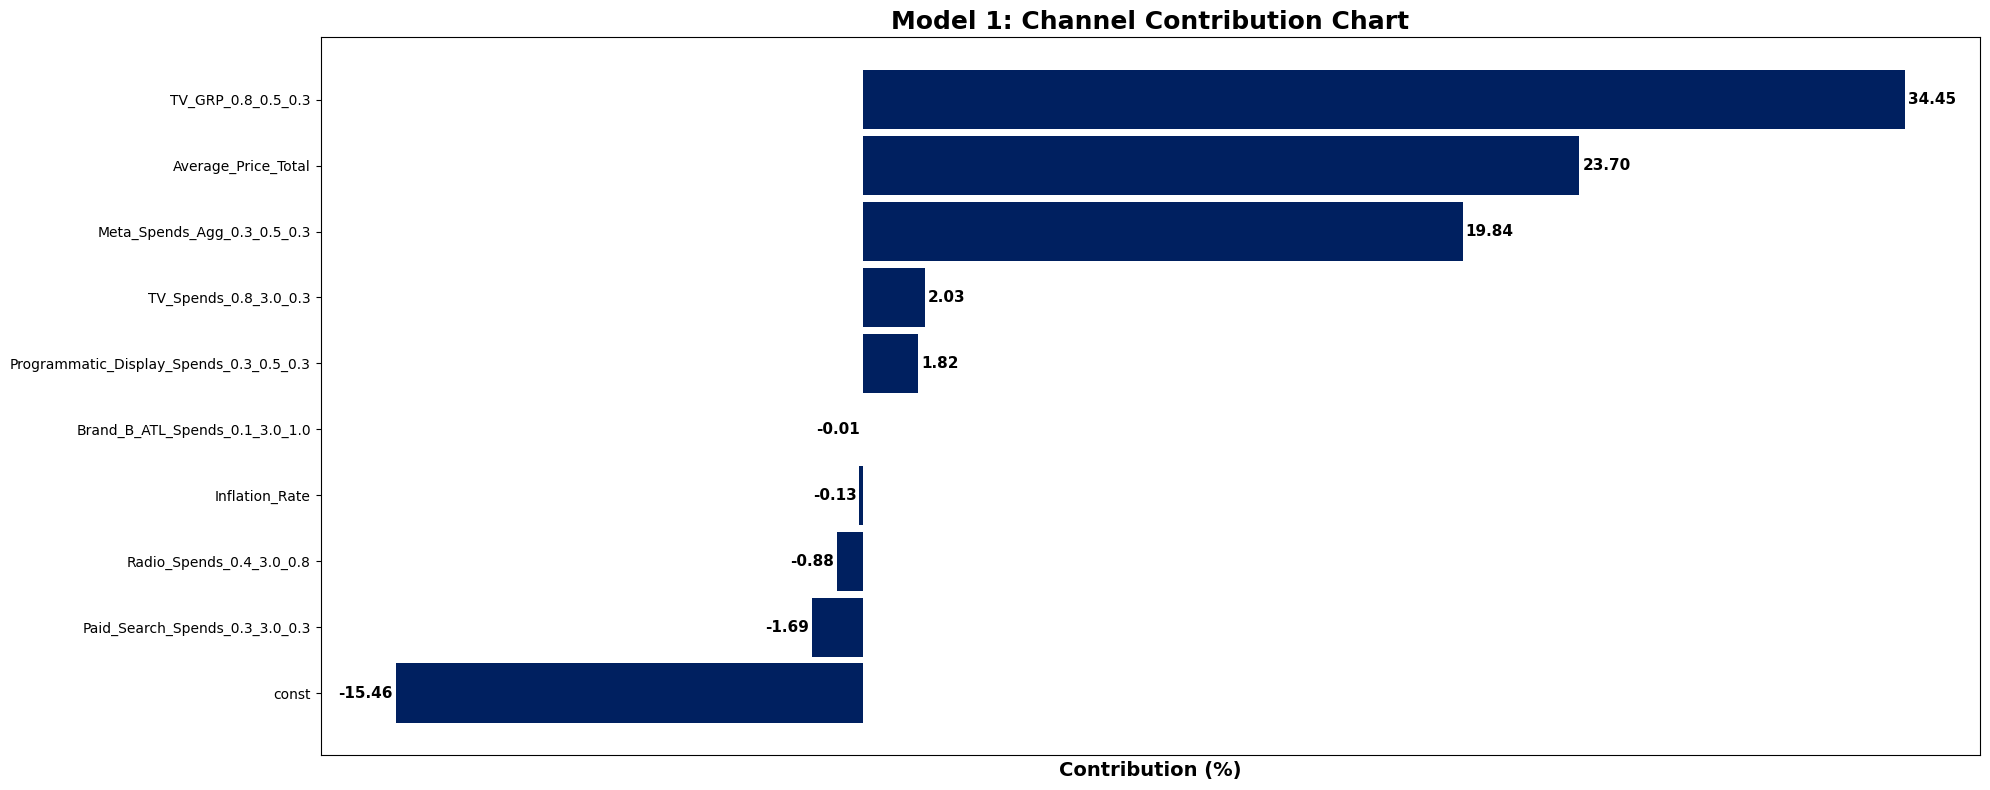

In [11]:
# Contribution bar chart
fig = create_contribution_plot(contrib1, title="Model 1: Channel Contribution Chart")
plt.show()

In [12]:
# DECOMP.RSSD: How well do spend shares align with effect shares?
# Lower is better -- means the model's attribution matches actual spending patterns
media_spend_vars_model1 = [v for v in model1_vars if v in paid_media]
rssd1 = compute_decomp_rssd(media_spend_vars_model1, contrib1, data)
print(f"Model 1 DECOMP.RSSD: {rssd1:.4f}")
print("(Lower = better alignment between spend share and effect share)")

Model 1 DECOMP.RSSD: 1.0898
(Lower = better alignment between spend share and effect share)


---

## Step 6: Iterate -- Model 2

Good modeling is **iterative**. Based on Model 1 diagnostics, we may want to:

- Remove variables with wrong signs.
- Remove variables with very high VIF (multicollinearity).
- Add or swap channels.
- Add additional control variables.

Let's build a second model spec.

In [13]:
# Model 2 specification: adjust based on Model 1 diagnostics
# Example: drop TV_GRP (collinear with TV_Spends), add Youtube_Spends
model2_vars = [
    "TV_Spends",
    "Paid_Search_Spends",
    "Programmatic_Display_Spends",
    "Meta_Spends_Agg",
    "Youtube_Spends",
    "Outdoor_Spends",
    "Brand_B_ATL_Spends",
]

# Build X matrix for Model 2
X_model2 = pd.DataFrame()

for var in model2_vars:
    best_row = best_df[best_df["Variable"] == var]
    if best_row.empty:
        print(f"WARNING: {var} not found in best_df, using raw values")
        X_model2[var] = data[var].values
    else:
        best_col = best_row["Best_Column"].values[0]
        X_model2[best_col] = all_transformed[var][best_col].values
        print(f"{var} -> {best_col} (r = {best_row['Correlation'].values[0]:.4f})")

# Add untransformed control variables
for var in untransformed:
    if var in data.columns:
        X_model2[var] = data[var].values
        print(f"{var} -> raw (untransformed control)")

print(f"\nX matrix shape: {X_model2.shape}")

TV_Spends -> TV_Spends_0.8_3.0_0.3 (r = 0.5624)
Paid_Search_Spends -> Paid_Search_Spends_0.3_3.0_0.3 (r = 0.3592)
Programmatic_Display_Spends -> Programmatic_Display_Spends_0.3_0.5_0.3 (r = 0.6347)
Meta_Spends_Agg -> Meta_Spends_Agg_0.3_0.5_0.3 (r = 0.7523)
Youtube_Spends -> Youtube_Spends_0.3_0.5_0.3 (r = 0.8038)
Outdoor_Spends -> Outdoor_Spends_0.4_3.0_1.0 (r = 0.2368)
Brand_B_ATL_Spends -> Brand_B_ATL_Spends_0.1_3.0_1.0 (r = 0.4813)
Inflation_Rate -> raw (untransformed control)
Average_Price_Total -> raw (untransformed control)

X matrix shape: (36, 9)


In [14]:
# Fit Model 2
model2 = build_ols_model(y, X_model2)
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     7.330
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           3.01e-05
Time:                        17:10:27   Log-Likelihood:                -423.37
No. Observations:                  36   AIC:                             866.7
Df Residuals:                      26   BIC:                             882.6
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [15]:
# Model 2 diagnostics
diag2 = model_diagnostics(model2, y)

# Side-by-side comparison
comparison = pd.DataFrame({
    "Metric": ["R_squared", "Adj_R_squared", "MAPE", "NRMSE", "AIC", "Durbin_Watson"],
    "Model_1": [
        diag1["R_squared"].iloc[0],
        diag1["Adj_R_squared"].iloc[0],
        diag1["MAPE"].iloc[0],
        diag1["NRMSE"].iloc[0],
        diag1["AIC"].iloc[0],
        diag1["Durbin_Watson"].iloc[0],
    ],
    "Model_2": [
        diag2["R_squared"].iloc[0],
        diag2["Adj_R_squared"].iloc[0],
        diag2["MAPE"].iloc[0],
        diag2["NRMSE"].iloc[0],
        diag2["AIC"].iloc[0],
        diag2["Durbin_Watson"].iloc[0],
    ],
})

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))

MODEL COMPARISON
       Metric    Model_1    Model_2
    R_squared   0.716170   0.717313
Adj_R_squared   0.617922   0.619459
         MAPE   0.042876   0.041502
        NRMSE   0.123696   0.123447
          AIC 866.889915 866.744737
Durbin_Watson   1.673454   1.943570


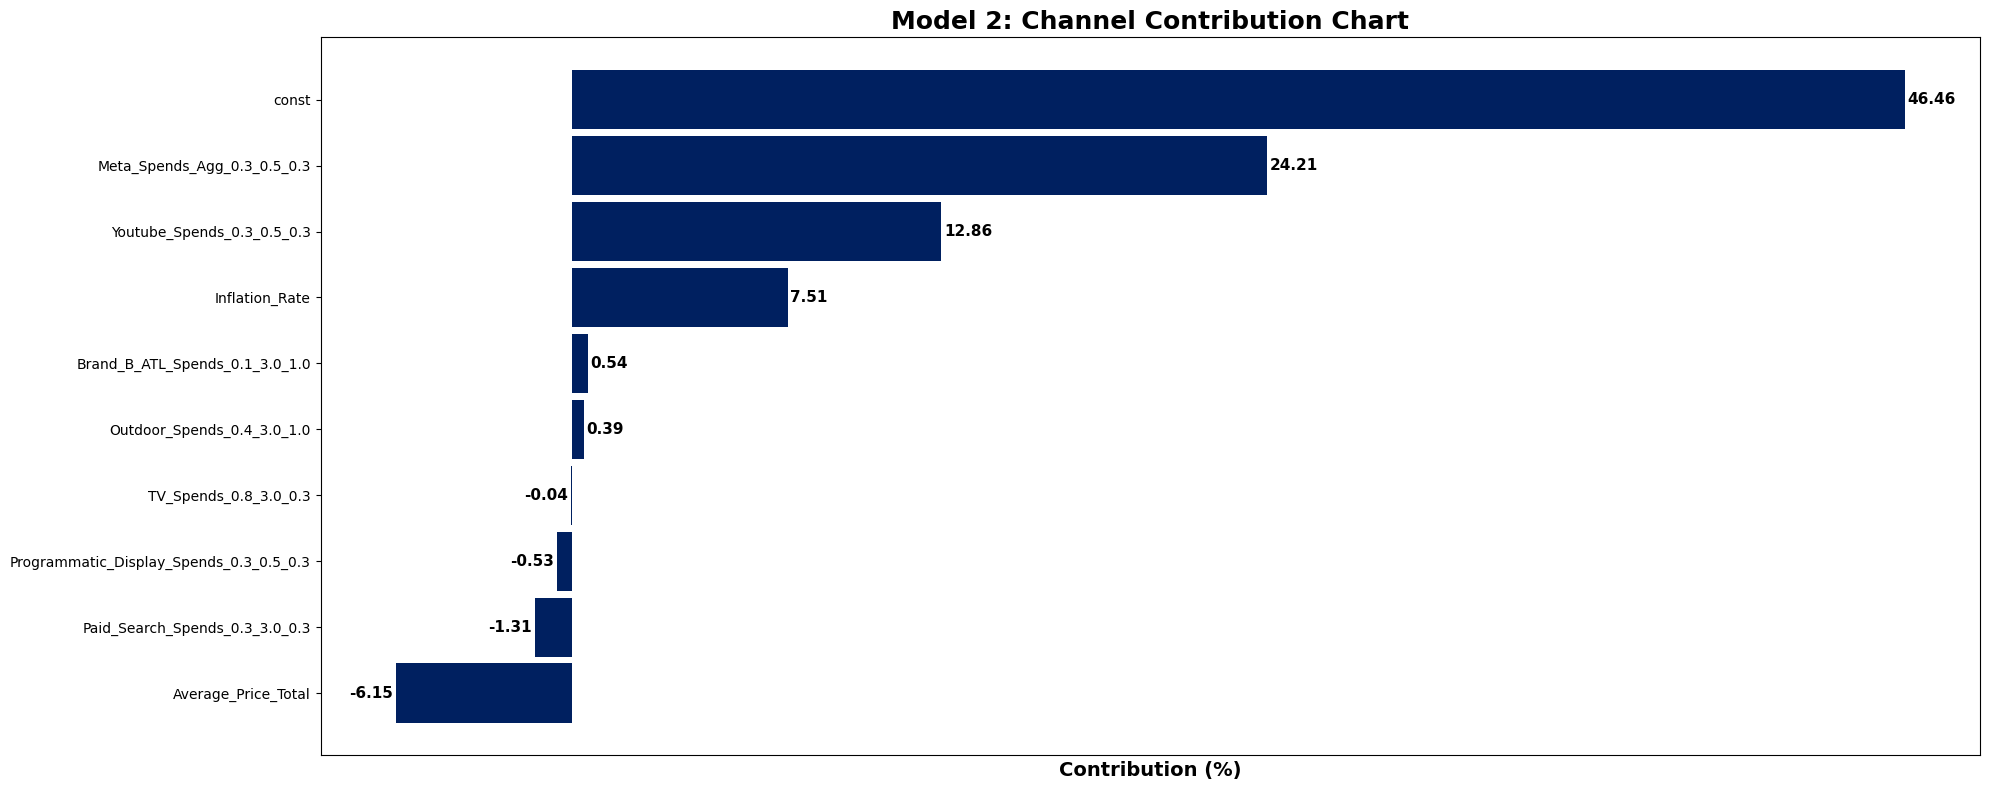

In [16]:
# Model 2 contributions
contrib2 = compute_contributions(model2)
fig = create_contribution_plot(contrib2, title="Model 2: Channel Contribution Chart")
plt.show()

---

## Exercise: Build Your Own Model Spec

Now it is your turn. Using the tools above, build **at least one more model** (Model 3).

Consider:
- Which variables had wrong signs? Remove them.
- Which variables had high VIF? Remove one from each correlated pair.
- Are there channels missing that should be included?
- Does adding impression-based variables (instead of spend) improve the model?

In [17]:
# TODO: Define your Model 3 variable list
model3_vars = [
    # Add your chosen variables here
]

# TODO: Build X matrix, fit model, run diagnostics, compute contributions
# Follow the same pattern as Model 1 and Model 2 above.

---

## Deliverable

By the end of this session, you should have:

1. A **working OLS MMM** using the workshop data.
2. **Contribution charts** for at least 2 model specifications.
3. A **comparison table** of diagnostics across your models.
4. An understanding of which variables drive sales and how transformation parameters affect results.

Save your notebook -- we will build on these results in **Session 4** when we move to Bayesian estimation.